# Tile generation on real OSN data — one tile, one date

Walks the surface-only tile path stage by stage on tile 330 (Monterey Bay),
so each intermediate is visible, then runs the whole thing through `run()`
and checks the NetCDF matches.

Needs network: the OSN kerchunk surface store is public/anonymous.


In [11]:
import logging
from pathlib import Path

import numpy as np
import xarray as xr
import yaml
import matplotlib.pyplot as plt

%matplotlib inline

from dbof.tiles import tile_utils as tu
from dbof.tiles.tile_mapping import rect_ij_to_tile
from dbof.tiles.field_registry import resolve_property

logging.basicConfig(level=logging.INFO, format="%(levelname)-6s %(message)s")

CONFIG = Path("../configs/tiles/tile330_gradb2_osn.yaml")
LON, LAT = -121.9, 36.8      # Monterey Bay, as the config header documents
PROPERTY = "gradb2"

cfg = yaml.safe_load(open(CONFIG))
DATE = str(cfg["data"]["date_iterations"][0])   # first of the 504 hourly dates
prop = resolve_property(PROPERTY)

print(f"date     {DATE}")
print(f"property {prop.name}  ({prop.long_name}) [{prop.units}]")
print(f"needs    {prop.vars_needed}   edge_margin={prop.edge_margin}")

date     2012-06-29 00:00:00
property gradb2  (squared buoyancy gradient magnitude) [s-4]
needs    ('Theta', 'Salt')   edge_margin=3


## 1. Source

`OSN` returns early with just `kind` + endpoint — no bucket/folder, because
kerchunk references don't have them. This is the switch the PR adds.

In [12]:
s3_cfg = tu._resolve_s3_source(None, pipeline="OSN")
s3_cfg

{'kind': 'OSN', 's3_endpoint': 'https://mghp.osn.xsede.org'}

## 2. Tile

lon/lat -> rect pixel -> tile. The config header expects face 10,
face-local j 0:720, i 2880:3600 — same block `resolve_chunk` picks.

In [13]:
i_rect, j_rect = tu.latlon_to_rect_ij(LON, LAT, s3_cfg)
tile = rect_ij_to_tile(i_rect, j_rect)

print(f"rect pixel  i={i_rect}  j={j_rect}")
print(f"tile        idx={tile.tile_idx}  face={tile.face_idx}")
print(f"            j={tile.j_face_slice}  i={tile.i_face_slice}")
assert tile.face_idx == 10, "config header expects face 10"

INFO   Resolving (lon=-121.9, lat=36.8) to a rect-grid pixel
/Users/lahoffma/miniforge3/envs/fronts/lib/python3.12/site-packages/xmitgcm/llcreader/llcmodel.py:322: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  data = np.arange(ifac * coords.dims[vname])
/Users/lahoffma/miniforge3/envs/fronts/lib/python3.12/site-packages/xmitgcm/llcreader/llcmodel.py:324: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  data = np.arange(jfac * coords.dims[vname])
INFO   Nearest rect pixel: (i=13252, j=9983) at (lon=-121.9062, lat=36.8014)


rect pixel  i=13252  j=9983
tile        idx=330  face=10
            j=slice(0, 720, None)  i=slice(2880, 3600, None)


## 3. Grid

The OSN grid doesn't come through the DEPTH reader, so `ensure_comodo_attrs`
is what puts the `axis` attrs on — without them xgcm can't find X/Y below.

In [14]:
ds_grid_tile = tu._load_grid_for_tile(s3_cfg, tile)

print(dict(ds_grid_tile.sizes))
print(sorted(ds_grid_tile.data_vars))
for dim in ("j", "j_g", "i", "i_g"):
    if dim in ds_grid_tile.dims:
        print(f"  {dim:4s} {ds_grid_tile.coords[dim].attrs}")

INFO   Loading grid (kind=OSN, face=10, j=slice(0, 720, None), i=slice(2880, 3600, None))


{'face': 1, 'j': 720, 'i': 720, 'i_g': 720, 'j_g': 720}
['CS', 'Depth', 'SN', 'XC', 'YC', 'dxC', 'dxG', 'dyC', 'dyG', 'hFacC', 'rA', 'rAz']
  j    {'axis': 'Y', 'long_name': 'y-dimension of the t grid', 'standard_name': 'y_grid_index', 'swap_dim': 'YC'}
  j_g  {'axis': 'Y', 'c_grid_axis_shift': -0.5, 'long_name': 'y-dimension of the v grid', 'standard_name': 'y_grid_index_at_v_location', 'swap_dim': 'YG'}
  i    {'axis': 'X', 'long_name': 'x-dimension of the t grid', 'standard_name': 'x_grid_index', 'swap_dim': 'XC'}
  i_g  {'axis': 'X', 'c_grid_axis_shift': -0.5, 'long_name': 'x-dimension of the u grid', 'standard_name': 'x_grid_index_at_u_location', 'swap_dim': 'XG'}


## 4. Tracers — surface only

The OSN reader already does `isel(time=0, k=0, k_l=0)`, so what arrives has
no vertical dim at all. That's the whole surface-only story.

In [15]:
ds_tracers_tile = tu._load_tracers_for_tile(
    s3_cfg, DATE, tile, vars_needed=list(prop.vars_needed))

print(dict(ds_tracers_tile.sizes))
print(sorted(ds_tracers_tile.data_vars))
assert "k" not in ds_tracers_tile.dims, "expected surface-only (no k)"
ds_tracers_tile

INFO   Opening timestep store for 2012-06-29 00:00:00 (kind=OSN, face=10, vars=['Theta', 'Salt'])


Opening 1 Kerchunk JSON files...
Parsing JSON metadata into Python dicts...
Creating lazy xarray datasets...
Computing delayed datasets...
Combining datasets by coordinates...
Dataset combined successfully.
{'face': 1, 'j': 720, 'i': 720}
['Salt', 'Theta']


<xarray.Dataset> Size: 4MB
Dimensions:  (face: 1, j: 720, i: 720)
Coordinates:
  * face     (face) float64 8B 10.0
  * j        (j) float64 6kB 0.0 1.0 2.0 3.0 4.0 ... 716.0 717.0 718.0 719.0
  * i        (i) float64 6kB 2.88e+03 2.881e+03 ... 3.598e+03 3.599e+03
    k        float64 8B 0.0
    k_l      float64 8B 0.0
    niter    float64 8B dask.array<chunksize=(), meta=np.ndarray>
    time     datetime64[ns] 8B 2012-06-29
Data variables:
    Theta    (face, j, i) float32 2MB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    Salt     (face, j, i) float32 2MB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
Attributes:
    history:  Created by C. Spencer Jones using https://github.com/cspencerjo...
    source:   MITgcm
    title:    Chunked netcdf created from MITgcm LLC4320 surface output

## 5. xgcm context

One face, so no face connections — stencils are invalid in an
`edge_margin`-cell rim, which shows up as NaN at the border later.

In [16]:
ds_merge, xgrid = tu._build_tile_context(ds_tracers_tile, ds_grid_tile)

print({ax: dict(xgrid.axes[ax].coords) for ax in xgrid.axes})
print(dict(ds_merge.sizes))

{'X': {'center': 'i', 'left': 'i_g'}, 'Y': {'center': 'j', 'left': 'j_g'}}
{'face': 1, 'j': 720, 'i': 720, 'i_g': 720, 'j_g': 720}


## 6. Compute

In [17]:
field = tu.compute_tile_property(ds_merge, xgrid, prop, mask_land=True)

nan_frac = float(np.isnan(field).mean())
finite = field.values[np.isfinite(field.values)]
print(f"dims   {dict(field.sizes)}  dtype={field.dtype}")
print(f"NaN    {nan_frac:.1%}  (edge rim {prop.edge_margin} cells + land mask)")
print(f"range  {finite.min():.3e} .. {finite.max():.3e}  median {np.median(finite):.3e}")

INFO   Computing gradb2 for tile (single .compute() over the lazy graph)


[########################################] | 100% Completed | 525.24 ms
dims   {'j': 720, 'i': 720}  dtype=float32
NaN    32.6%  (edge rim 3 cells + land mask)
range  2.525e-19 .. 8.770e-12  median 1.952e-15


## 7. Look at it

`gradb2` spans orders of magnitude, so plot log10 on robust limits.

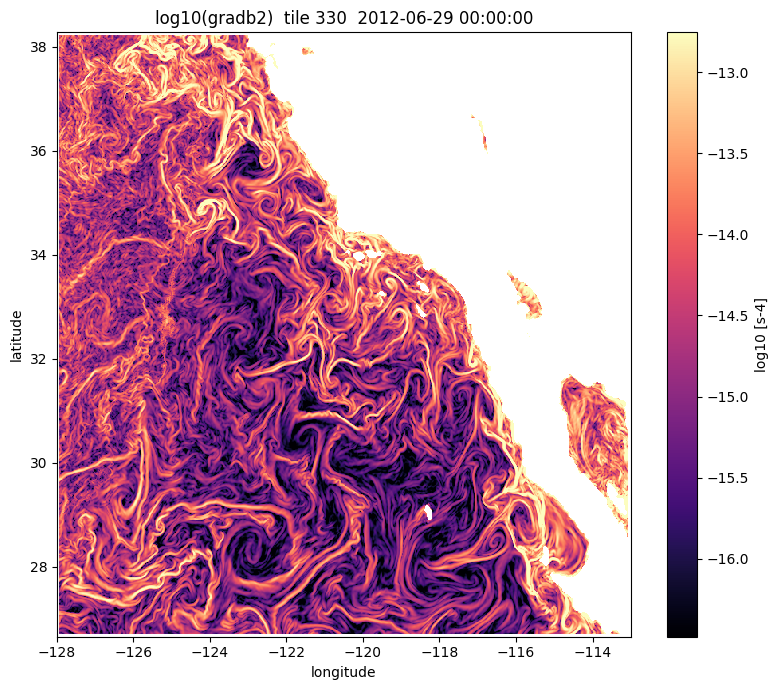

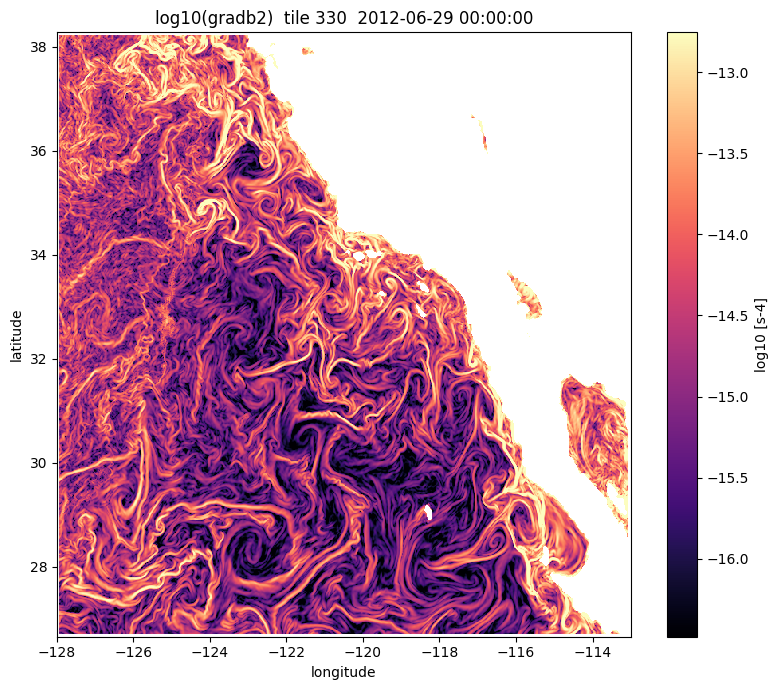

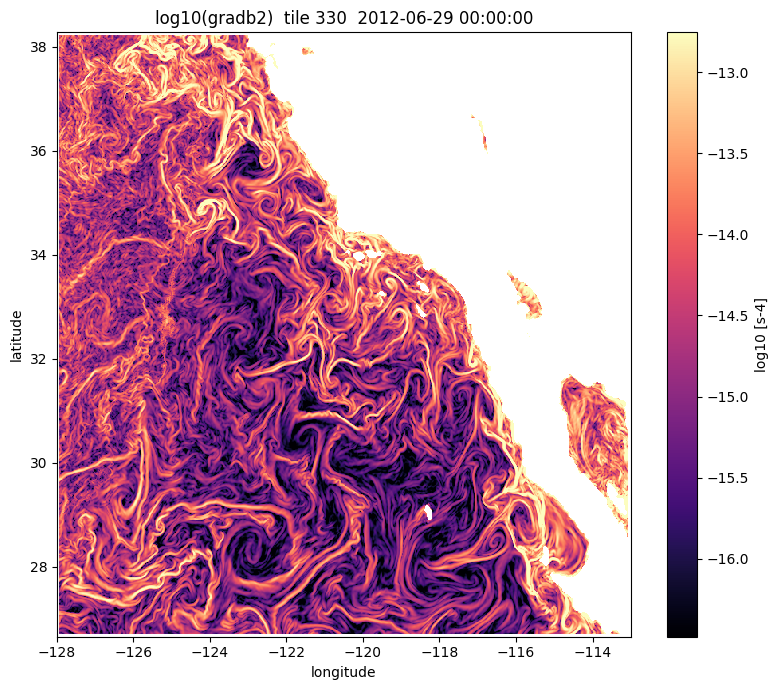

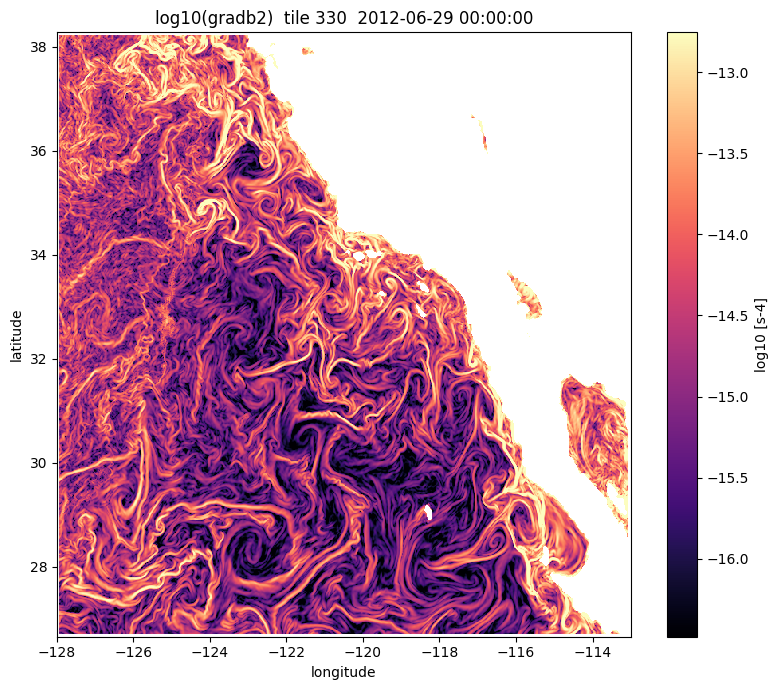

In [18]:
vals = np.log10(np.where(field.values > 0, field.values, np.nan))
lo, hi = np.nanpercentile(vals, [2, 98])

fig, ax = plt.subplots(figsize=(8, 7))
pcm = ax.pcolormesh(ds_grid_tile["XC"].squeeze().values,
                    ds_grid_tile["YC"].squeeze().values,
                    vals, vmin=lo, vmax=hi, shading="auto", cmap="magma")
ax.set(xlabel="longitude", ylabel="latitude",
       title=f"log10({prop.out_name})  tile {tile.tile_idx}  {DATE}")
fig.colorbar(pcm, ax=ax, label=f"log10 [{prop.units}]")
fig.tight_layout()
plt.show()


## 8. End to end

Same thing through `run()`, which adds the output dataset, provenance attrs
and the NetCDF write. The field should be identical to step 6.

In [19]:
out_dir = Path("./_osn_tile_check")
out_path = tu.run(
    lon=LON, lat=LAT, timestamp=DATE, property=PROPERTY,
    pipeline="OSN", config_path=None,
    output=str(out_dir), clobber=True, gen_qa_plot=True,
)
print(out_path)

ds_out = xr.open_dataset(out_path)
np.testing.assert_allclose(ds_out[prop.out_name].values, field.values, equal_nan=True)
print("matches the stepwise field")
ds_out

INFO   Resolving (lon=-121.9, lat=36.8) to a rect-grid pixel
/Users/lahoffma/miniforge3/envs/fronts/lib/python3.12/site-packages/xmitgcm/llcreader/llcmodel.py:322: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  data = np.arange(ifac * coords.dims[vname])
/Users/lahoffma/miniforge3/envs/fronts/lib/python3.12/site-packages/xmitgcm/llcreader/llcmodel.py:324: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  data = np.arange(jfac * coords.dims[vname])
INFO   Nearest rect pixel: (i=13252, j=9983) at (lon=-121.9062, lat=36.8014)
INFO   Resolved tile: idx=330 (tile_j_rect=13, tile_i_rect=18)  face=10 

Opening 1 Kerchunk JSON files...
Parsing JSON metadata into Python dicts...
Creating lazy xarray datasets...
Computing delayed datasets...


INFO   Computing gradb2 for tile (single .compute() over the lazy graph)


Combining datasets by coordinates...
Dataset combined successfully.
[########################################] | 100% Completed | 524.47 ms


INFO   Saving NetCDF: /Users/lahoffma/projects/Sea-Meets-the-Stars/llc4320-native-grid-preprocessing/dev/_osn_tile_check
INFO   Saving QA plot: /Users/lahoffma/projects/Sea-Meets-the-Stars/llc4320-native-grid-preprocessing/dev/_osn_tile_check.png


/Users/lahoffma/projects/Sea-Meets-the-Stars/llc4320-native-grid-preprocessing/dev/_osn_tile_check
matches the stepwise field


<xarray.Dataset> Size: 10MB
Dimensions:       (j: 720, i: 720)
Coordinates: (12/13)
  * j             (j) int64 6kB 0 1 2 3 4 5 6 7 ... 713 714 715 716 717 718 719
  * i             (i) int64 6kB 2880 2881 2882 2883 2884 ... 3596 3597 3598 3599
    face          int64 8B ...
    k             float64 8B ...
    k_l           float64 8B ...
    niter         float64 8B ...
    ...            ...
    XC            (j, i) float64 4MB ...
    YC            (j, i) float64 4MB ...
    tile_index    int64 8B ...
    face_index    int64 8B ...
    rect_i_start  int64 8B ...
    rect_j_start  int64 8B ...
Data variables:
    gradb2        (j, i) float32 2MB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    timestamp:      2012-06-29 00:00:00
    iteration:      1002240
    tile_index:     330
    tile_j_rect:    13
    tile_i_rect:    18
    face_index:     10
    rect_i_user:    13252
    rect_j_user:    9983
    property:       gradb2
    edge_margin:    3
    source_script:  src/dbof/cli/generate_tile.py
    git_commit:     cd31497

In [20]:
{k: ds_out.attrs[k] for k in sorted(ds_out.attrs)}

{'edge_margin': np.int64(3),
 'face_index': np.int64(10),
 'git_commit': 'cd31497',
 'iteration': np.int64(1002240),
 'property': 'gradb2',
 'rect_i_user': np.int64(13252),
 'rect_j_user': np.int64(9983),
 'source_script': 'src/dbof/cli/generate_tile.py',
 'tile_i_rect': np.int64(18),
 'tile_index': np.int64(330),
 'tile_j_rect': np.int64(13),
 'timestamp': '2012-06-29 00:00:00'}